# Machine Learning for Seismometer Placement Optimization
- Year : 2025-2026
- Author : Romain Markowitch
## Problem statement

We consider a two-dimensional seismic domain. The earthquake events are synthetically
generated inside the domain. Each event activates a seismic source at an unknown epicenter $(e_x, e_y)$.
The resulting acoustic waves propagate through the medium according to the acoustic wave equation :
$$\frac{\partial^2 u}{\partial t^2} = c(x,y)^2\,\nabla^2 u + f(x, y, t, e_x, e_y, t_0)$$
where $c(x,y)$ is the wave propagation speed and $f$ is a Ricker wavelet source.
The waves are recorded by $K$ interrogators at fixed positions, producing seismograms.

The forward problem consists in computing those seismograms for a given epicenter.
The inverse problem consists in recovering the epicenter by minimizing the misfit between
predicted and observed seismograms. The placement optimization asks where to put the
interrogators to minimize the expected localization error across many epicenters.

Two velocity fields are used : a constant field ($c = 5$ m/s) and the heterogeneous
Marmousi field normalized to a maximum of 7 m/s.

## Differentiable solver

The differentiable solver integrates the wave equation on the grid using an
explicit finite-difference scheme. All operations are implemented in PyTorch. This makes the
simulation fully differentiable with respect to $(e_x, e_y)$. This allows gradient-based
epicenter inversion by backpropagation through the time-stepping loop without any
precomputed dataset. It serves as the reference forward operator throughout the experiments.

Its main limitation is computational cost, each forward pass requires stepping through the
full grid for all time steps. It becomes very expensive in the bilevel placement loop.

## PINN surrogate

The PINN is a fully connected network $u_\theta : \mathbb{R}^6 \rightarrow \mathbb{R}$
taking $(x, y, t, e_x, e_y, t_0)$ as input. A single network covers the source
locations without needing to be retrained. Its output is multiplied by a causal multiplier that enforce, by constructions, zero pressure before the source activation.

It is trained by minimizing the PDE residual at randomly sampled collocation points. 
It also uses a small regularization term to prevent the trivial zero solution. No seismogram
data is used during training.

Once trained, it is wrapped in a solver with the same interface as the differentiable
solver, making both interchangeable in the inversion and placement loops. The PINN
reduces the evaluation cost by $241\times$ for the forward pass and $657\times$
for the full inversion.

Note that most plots are functions that have been improved by using AI (claude sonnet 4.6) to make them clearer and more easily interpretable.

Moreover, most functions for the models and optimization can be found in M2 folder.

In [ ]:
# Imports
%load_ext autoreload # avoid having to restart the kernel after editing a file
%autoreload 2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.ndimage import zoom
from scipy.interpolate import RegularGridInterpolator

from M2.DP import DPForwardSolver
from M2.Utils.source import source
from M2.PINN.model import PINN, PINNForwardSolver, g
from M2.PINN.loss import loss_fn
from M2.inverse_problem import inverse_function
from M2.placement import optimize_sensors, local_search

device = "cpu"

## PINN trainning : 

The training procedure below was provided by Pascal Tribel.

We train the PINN by minimizing the PDE residual over randomly sampled collocation points.
At each step, we draw $N = 5 \times 10^4$ points uniformly: $x \in [-10, 10]$, $y \in [-10, 10]$,
$t \in [0, 15]$, $x_0 \in [-5, 5]$, $y_0 \in [-5, 5]$, and $t_0 \in [0.5, 2.5]$.
The velocity field $c(x, y)$ is not sampled; it is evaluated at the collocation points inside the loss function.
The total loss combines the PDE residual term and a zero-regularization term weighted by $10^{-1}$.
We optimize with AdamW at a learning rate of $5 \times 10^{-3}$ for $50\,000$ steps,
with gradient clipping at norm $1.0$.

`run_fd_reference` implements a finite-difference reference solver on a uniform grid.
It applies the explicit update rule and records pressure traces at three fixed receiver positions.
It serves as ground truth to assess PINN quality during training.

`check_seismograms` queries the PINN at some fixed receiver positions and overlays
the predicted traces against the finite-difference reference.
It is called every `CKPT_EVERY` steps during training and whenever a new loss minimum is reached.
Each call appends a frame to a GIF so training progression can be reviewed afterward.

In [ ]:
import io
import imageio.v2 as iio2
from IPython.display import display, Image

def run_fd_reference(t_max: float = 5.0, L: float = 50.0, nx: int = 500, t0=1, cx=0, cy=0, cfl_target: float = 0.75*1/(2**0.5)):
    dx = L * 2 / nx
    x1d = np.linspace(-L, L, nx)
    X, Y = np.meshgrid(x1d, x1d, indexing="ij")
 
    Z = c(X, Y).cpu().numpy()
    c_max = np.max(Z).item()
    dt = cfl_target * dx / c_max
    n_t = int(np.ceil(t_max / dt))
    r2 = (Z * dt / dx) ** 2
 
    p_prev = np.zeros((nx, nx))
    p_curr = np.zeros((nx, nx))
 
    def idx(v): return int(round((v + L) / dx))
    rec_pts = {
        "(-1.2,3)":   (idx(-1.2), idx(3)),
        "(0.1,-0.4)": (idx(0.1),  idx(-0.4)),
        "(4,-4.5)": (idx(4), idx(-4.5))
    }
    traces = {k: np.zeros(n_t) for k in rec_pts}
    t_arr  = np.linspace(0, t_max, n_t)
 
    for it, t in enumerate(t_arr):
        lap = (p_curr[2:,  1:-1] + p_curr[:-2, 1:-1] +
               p_curr[1:-1, 2:] + p_curr[1:-1, :-2] -
               4.0 * p_curr[1:-1, 1:-1])
 
        src = source(torch.tensor(X), torch.tensor(Y), torch.tensor(t),
                     t0=t0, cx=cx, cy=cy).numpy()[1:-1, 1:-1]
 
        p_next = np.zeros_like(p_curr)
        p_next[1:-1, 1:-1] = (
            2.0 * p_curr[1:-1, 1:-1]
            - p_prev[1:-1, 1:-1]
            + r2[1:-1, 1:-1] * lap
            + dt**2 * src
        )
 
        for k, (ix, iy) in rec_pts.items():
            traces[k][it] = p_next[ix, iy]
 
        p_prev, p_curr = p_curr, p_next
 
    return t_arr, traces
 


gif_frames = []
GIF_PATH   = "training_progress.gif"
_gif_display_handle = None

receiver_labels=["(-1.2,3)", "(0.1,-0.4)", "(4,-4.5)"]

def check_seismograms(model=None, t_max: float = 10.0, t_0=[1.], cx=0, cy=0):
    if model == None:
        model = torch.load("model.pt", weights_only=False)
    global gif_frames, _gif_display_handle
    plt.figure(figsize=(20, 10))
    for i in range(len(t_0)):
        t_fd, fd_seis = run_fd_reference(t_max=t_max, t0=t_0[i], cx=cx, cy=cy)
        n_t = len(t_fd)
        x  = torch.ones(n_t, 1, device=device)
        y  = torch.ones(n_t, 1, device=device)
        t  = torch.tensor(t_fd, dtype=torch.float32, device=device).unsqueeze(1)
        t_np = t_fd
        t0 = torch.ones_like(t, device=device) * t_0[i]
        with torch.no_grad():
            p_neg1 = model(-1.2*x, 3*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_zero = model(0.1*x, -0.4*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_one = model(4*x, -4.5*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            pinn_seis = {'(-1.2,3)': p_neg1, '(0.1,-0.4)': p_zero, "(4,-4.5)": p_one}
        for label in receiver_labels:
            plt.plot(t_np, pinn_seis[label], label=f'PINN {label}',   linewidth=1.5)
            plt.plot(t_fd, fd_seis[label],   label=f'FD ref {label}', linewidth=1.5, linestyle='--')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.xlim([0, t_max])
        plt.ylim([-5, 5])
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.title(
        f"Seismograms - src=({cx},{cy})  "
        f"Iteration {(len(gif_frames)+1)}  (PINN vs FD reference)",
        fontsize=13,
    )
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    gif_frames.append(buf.read())
    plt.close()
    if len(gif_frames) >= 1:
        import imageio.v2 as iio2
        imgs = [iio2.imread(io.BytesIO(f)) for f in gif_frames]
 
        with iio2.get_writer(GIF_PATH, mode="I", loop=0) as writer:
            for i, img in enumerate(imgs):
                repeats = 4 if i == len(imgs) - 1 else 1
                for _ in range(repeats):
                    writer.append_data(img, {"duration": 100})
    gif_bytes = open(GIF_PATH, "rb").read()
    if _gif_display_handle is None:
        _gif_display_handle = display(
            Image(data=gif_bytes, format="gif"),
            display_id="seismo_gif"
        )
    else:
        _gif_display_handle.update(Image(data=gif_bytes, format="gif"))

Trainning :

In [ ]:
from torch.nn import DataParallel
n_gpus = torch.cuda.device_count()

TRAINING = True
_gif_display_handle = None
gif_frames = []

if TRAINING:
    min_loss = 5e-2
    model = PINN().to(device)
    #torch.save(model, "model.pt")
    
    if n_gpus > 1:
        model = DataParallel(model)
    
    N_POINTS      = int(5e4)
    SPATIAL_RANGE_X  = 10.0
    SPATIAL_RANGE_Y  = 10.0
    SPATIAL_RANGE_X0 = 5.0
    SPATIAL_RANGE_Y0 = 5.0
    T0_MAX        = 2.0
    T_MAX         = 15.0
    N_STEPS       = 50_000
    LR            = 5e-3
    CKPT_EVERY    = 500
    
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.75, patience=25)
    
    def sample_batch():
        x  = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_X
        y  = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_Y
        t = torch.rand(N_POINTS, 1, device=device) * T_MAX
        x0 = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_X0
        y0 = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_Y0
        t0 = (torch.rand(N_POINTS, 1, device=device) * (T0_MAX-0.5)) + 0.5
        return x, y, t, x0, y0, t0
    
    losses = [[], []]
    for step in (pbar := tqdm(range(N_STEPS))):
        x, y, t, x0, y0, t0 = sample_batch()
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)
        t = t.requires_grad_(True)
        optimizer.zero_grad(set_to_none=True)
        loss_pde, loss_zero = loss_fn(model, x, y, t, x0, y0, t0)
        (loss_pde+1e-1*loss_zero).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        #scheduler.step(loss_pde)
        losses[0].append(loss_pde.item())
        losses[1].append(loss_zero.item())
        pbar.set_description(f"Loss PDE={np.mean(losses[0][-20:]):.3e}; Loss Zero={np.mean(losses[1][-20:]):.3e}")
        if step % CKPT_EVERY == CKPT_EVERY-1:
            check_seismograms(model)
        if loss_pde.item() < min_loss:
            min_loss = loss_pde.item()
            torch.save(model, "model.pt")
            check_seismograms()
else:
    model = torch.load("model.pt", weights_only=False)
    check_seismograms(model)

## Experiments :

The following experiments realized for the master thesis - "ML for seismometer placement optimization", evaluate the differentiable solver and the PINN surrogate
across different axes: batch inversion accuracy, spatial error distribution, noise robustness,
effect of interrogator count and interrogator placement optimization.
Both solvers are tested on two velocity fields, a constant field and the Marmousi field.

### Setup :
Paramters used for the experiments :

In [ ]:
# Symmetric sensor configurations
sensors_2 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0]], device="cpu")
sensors_3 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0], [ 0.0, 1.0]], device="cpu")
sensors_4 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0], [ 0.0,-1.0], [ 0.0, 1.0]], device="cpu")

sensors_asym = torch.tensor([[-1.0, 0.0], [1.0, 0.5]], device="cpu")

# Domain and simulation parameters
x_min, x_max, y_min, y_max = -50, 50, -50, 50
nx, ny = 500, 500
T, Nt = 5.0, 250  
A = 100.0
t0_src = 1.0
f0 = 1.0
gamma = 0.5 # -> sigma=1

init_guess = (1.0, 1.0)
true_ex, true_ey = 0, 0

torch.manual_seed(42)
N_EPI = 20
epicenters = torch.rand(N_EPI, 2) * 8 - 4   # uniform in [-4, 4]^2

We use two velocity fields throughout the experiments :
- The constant field sets $c = 5$ m/s everywhere, providing a controlled homogeneous baseline.
- The heterogeneous field is the Marmousi benchmark model, normalized to a maximum of 7 m/s to remain physically consistent with the homogeneous case. The Marmousi field is interpolated onto the simulation grid using nearest-neighbor interpolation.

In [80]:
# Heterogeneous c from Marmousi
vp = np.load("M2/Utils/marmousi_vp.npy")
vp_normalized = vp / vp.max() * 7 # normalize to be physically consistent with the homogeneous case

x_coords = np.linspace(-5, 5, vp.shape[0]) 
y_coords = np.linspace(-5, 5, vp.shape[1])

interp_marmousi = RegularGridInterpolator((x_coords, y_coords), vp_normalized, method='nearest', bounds_error=False, fill_value=None)

def c_marmousi(x, y, t=0):
    if isinstance(x, torch.Tensor): 
        x = x.cpu().detach().numpy()
    if isinstance(y, torch.Tensor): 
        y = y.cpu().detach().numpy()
    return torch.tensor(interp_marmousi(np.stack([x.ravel(), y.ravel()], axis=-1)).reshape(x.shape),dtype=torch.float32)

# Constant c
def c_constant(x, y, t=0):
    if type(y) == np.ndarray:
        y = torch.tensor(y)
    if type(x) == np.ndarray:
        x = torch.tensor(x)
    return 5*torch.ones_like(y)

#### Visual : 
Normalized Marmousi field :

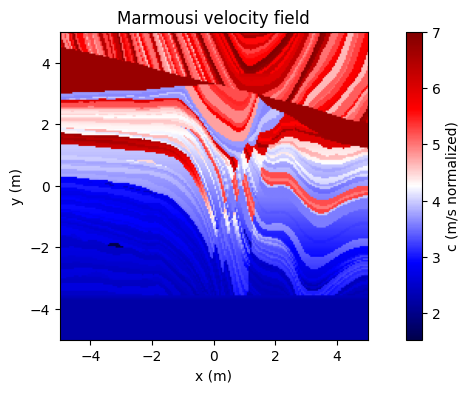

In [6]:
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = c_marmousi(X, Y)

plt.figure(figsize=(10, 4))
plt.imshow(Z.T, extent=[-5,5,-5,5], origin="lower", cmap="seismic", aspect="equal")
plt.colorbar(label="c (m/s normalized)")
plt.title("Marmousi velocity field")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

Ricker wavelet, the seismic source : 

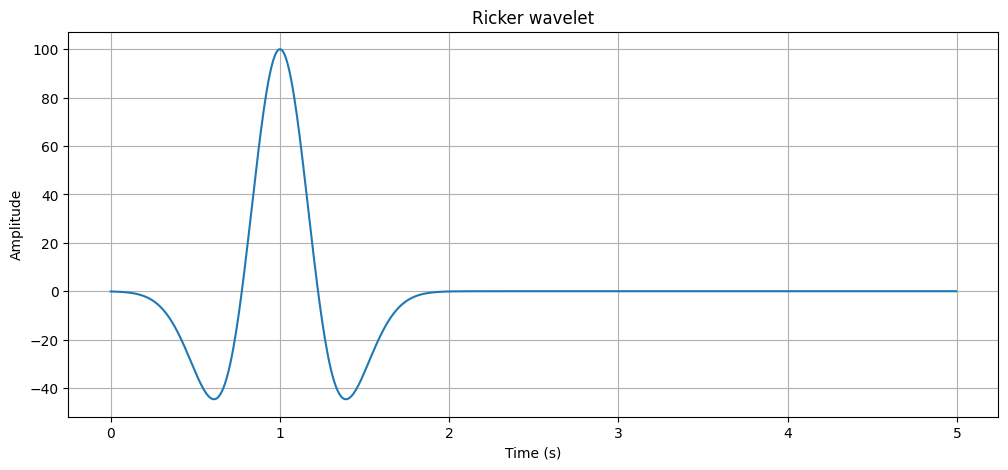

In [7]:
n_t = 1000
plt.figure(figsize=(12, 5))
plt.plot(torch.arange(0, 5, 5/n_t), source(torch.zeros(n_t), torch.zeros(n_t), torch.arange(0, 5, 5/n_t), 0, 0))
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Ricker wavelet")
plt.grid()
plt.show()

The PINN output is multiplied by the causal gate $g(t, t_0) = \frac{1}{2}(\tanh(\alpha(t - t_0 + t_0/10)) + 1)$.
This enforces a near-zero field before the source activates, approximating the zero initial condition by construction without requiring an explicit boundary loss term.

Text(0, 0.5, 'g(t)')

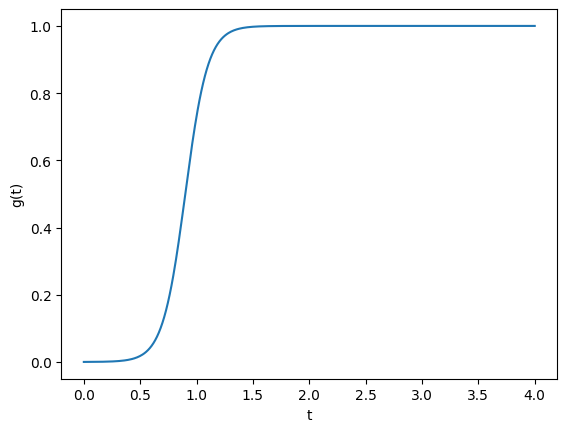

In [81]:
plot_t0 = 1.0
plot_t = torch.linspace(0, 4, 500)
plot_y = 0.5 * (torch.tanh(5.0 * (plot_t - plot_t0 + plot_t0/10)) + 1)

plt.plot(plot_t, plot_y)
plt.xlabel("t")
plt.ylabel("g(t)")

#### Solvers :
Configure solvers with the experiments parameters :

In [3]:
# Create a DP solver with the same parameters for all experiments
def make_dp(sensors, c_fn):
    return DPForwardSolver(
        sensors=sensors, c_fn=c_fn,
        x_min=x_min, x_max=x_max,
        y_min=y_min, y_max=y_max,
        Nx=nx, Ny=ny, Nt=Nt, T=T,
        A=A, t0=t0_src, f0=f0, gamma=gamma,
        device="cpu",
    )

# Create a PINN model with the same architecture for all experiments
def make_pinn(sensors, model):
    return PINNForwardSolver(
        model=model,
        sensors=sensors,
        t_max=T, n_t=Nt,
        x_min=x_min, x_max=x_max,
        y_min=y_min, y_max=y_max,
        device="cpu",
    )

Differentiable solver configurations : 

In [ ]:
# Create DP solvers for all configurations
dp_const = make_dp(sensors_2, c_constant)
dp_hetero = make_dp(sensors_2, c_marmousi)

dp_const_asym = make_dp(sensors_asym, c_constant)
dp_hetero_asym = make_dp(sensors_asym, c_marmousi)

PINN configurations :

In [ ]:
# PINN model trained on constant c
model_pinn_const = torch.load("M2/Utils/model_pinn_constant.pt", map_location=device, weights_only=False)
model_pinn_const.eval()

pinn_solver_const = make_pinn(sensors_2, model_pinn_const)
pinn_solver_const_asym = make_pinn(sensors_asym, model_pinn_const)

# PINN model trained on Marmousi
model_pinn_marmousi = torch.load("M2/Utils/model_marmousi.pt", map_location=device, weights_only=False)
model_pinn_marmousi = model_pinn_marmousi.module  # unwrap DataParallel
model_pinn_marmousi.eval()

pinn_solver_marmousi = make_pinn(sensors_2, model_pinn_marmousi)
pinn_solver_marmousi_asym = make_pinn(sensors_asym, model_pinn_marmousi)

Generate the traces (observed/reference) seismograms. Used as truth for the experiments.

In [38]:
traces_obs_constant = dp_const.forward(e_x=true_ex, e_y=true_ey).detach()
traces_obs_hetero = dp_hetero.forward(e_x=true_ex, e_y=true_ey).detach()
traces_pinn_const = pinn_solver_const.forward(e_x=true_ex, e_y=true_ey).detach()
traces_pinn_hetero = pinn_solver_marmousi.forward(e_x=true_ex, e_y=true_ey).detach()

We plot the seismograms produced by the differentiable solver and the PINN for the epicenter at the origin.
This gives a first visual check of the quality gap between the two forward operators before any inversion is run.
A systematic amplitude or phase difference here propagates into inversion error in all experiments below.

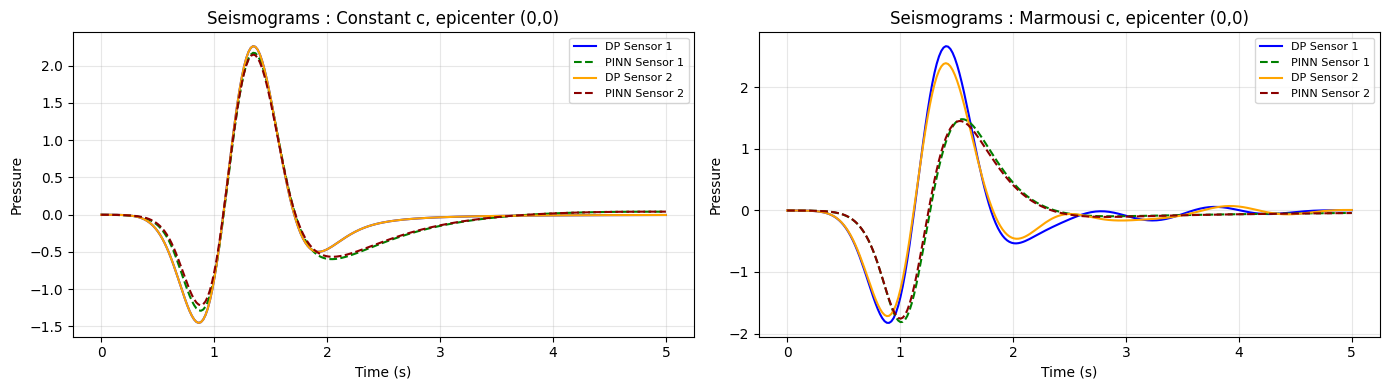

In [19]:
t_axis = np.linspace(0, T, Nt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dp_colors   = ["blue", "orange"]   # blue, orange for DP
pinn_colors = ["green", "darkred"]   # green, dark red for PINN

for ax, dp_traces, pinn_traces, label in zip(
    axes,
    [traces_obs_constant, traces_obs_hetero],
    [traces_pinn_const, traces_pinn_hetero],
    ["Constant c", "Marmousi c"]
):
    for k in range(dp_traces.shape[1]):
        ax.plot(t_axis, dp_traces[:, k],
                color=dp_colors[k], linewidth=1.5,
                linestyle="-", label=f"DP Sensor {k+1}")
        ax.plot(t_axis, pinn_traces[:, k],
                color=pinn_colors[k], linewidth=1.5,
                linestyle="--", label=f"PINN Sensor {k+1}")
    ax.set_title(f"Seismograms : {label}, epicenter (0,0)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pressure")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Batch accuracy :
Test the differentiable solver and the PINN on a batch of epicenter in the domain to test their inversion quality.

`run_inversion_batch` runs the inversion loop over all test epicenters for a given solver.
Observations are generated by the same solver, so the result measures self-consistency.

`run_inversion_batch2` uses a different solver to generate the observations.
This tests the cross-model gap, how well a solver inverts seismograms it did not produce.
A large error here indicates that the two solvers produce systematically different traces.

In [ ]:
# Inversion batch function
def run_inversion_batch(solver, epicenters, steps=10, lr=1, max_iter=3):
    errors = []
    for m in tqdm(range(len(epicenters))):
        ex, ey = epicenters[m, 0].item(), epicenters[m, 1].item()
        traces_obs = solver.forward(ex, ey).detach()
        e_hat, _, _, _ = inverse_function(
            forward=solver, traces_obs=traces_obs,
            dt=solver.dt, init=init_guess,
            steps=steps, lr=lr, max_iter=max_iter,
            device="cpu", show_progress=False,
        )
        err = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
        errors.append(err)
    return np.array(errors)

# Additional batch function to compare DP and PINN on the same plot
def run_inversion_batch2(solver, trace_solver, epicenters, steps=10, lr=1, max_iter=3):
    errors = []
    for m in tqdm(range(len(epicenters))):
        ex, ey = epicenters[m, 0].item(), epicenters[m, 1].item()
        traces_obs = trace_solver.forward(ex, ey).detach()
        e_hat, _, _, _ = inverse_function(
            forward=solver, traces_obs=traces_obs,
            dt=solver.dt, init=init_guess,
            steps=steps, lr=lr, max_iter=max_iter,
            device="cpu", show_progress=False,
        )
        err = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
        errors.append(err)
    return np.array(errors)

#### Differentiable solver :
Run the differentiable solver with the symmetric and asymetric configurations :

In [ ]:
errors_const = run_inversion_batch(dp_const, epicenters)
errors_hetero = run_inversion_batch(dp_hetero, epicenters)

errors_const2 = run_inversion_batch(dp_const_asym,  epicenters)
errors_hetero2 = run_inversion_batch(dp_hetero_asym, epicenters)

100%|██████████| 20/20 [07:25<00:00, 22.30s/it]


#### PINN :
Run the PINN with the symmetric and asymetric configurations :

In [ ]:
errors_const_pinn = run_inversion_batch(pinn_solver_const, epicenters)
errors_const2_pinn = run_inversion_batch(pinn_solver_const_asym, epicenters)

errors_hetero_pinn = run_inversion_batch(pinn_solver_marmousi, epicenters)
errors_hetero2_pinn = run_inversion_batch(pinn_solver_marmousi_asym, epicenters)

100%|██████████| 20/20 [00:00<00:00, 24.82it/s]


#### Results :
##### Boxplot : 
Plot the results as a boxplot.

In [82]:
# Define colors for the plots
COLOR_CONST_SYM = "blue"  # blue
COLOR_CONST_ASYM = "#7AB3E0"  # light blue
COLOR_MAR_SYM = "orange"  # orange
COLOR_MAR_ASYM = "#F5C49A"  # light orange
COLOR_PINN_SYM = "green"   # green
COLOR_PINN_ASYM = "#A8D5A2"  # light green
COLOR_PINN_MAR_SYM = "red"    # red
COLOR_PINN_MAR_ASYM = "#F5A9A9"  # light red

colors = [COLOR_CONST_SYM, COLOR_CONST_ASYM, COLOR_MAR_SYM, COLOR_MAR_ASYM, 
          COLOR_PINN_SYM, COLOR_PINN_ASYM, COLOR_PINN_MAR_SYM, COLOR_PINN_MAR_ASYM]

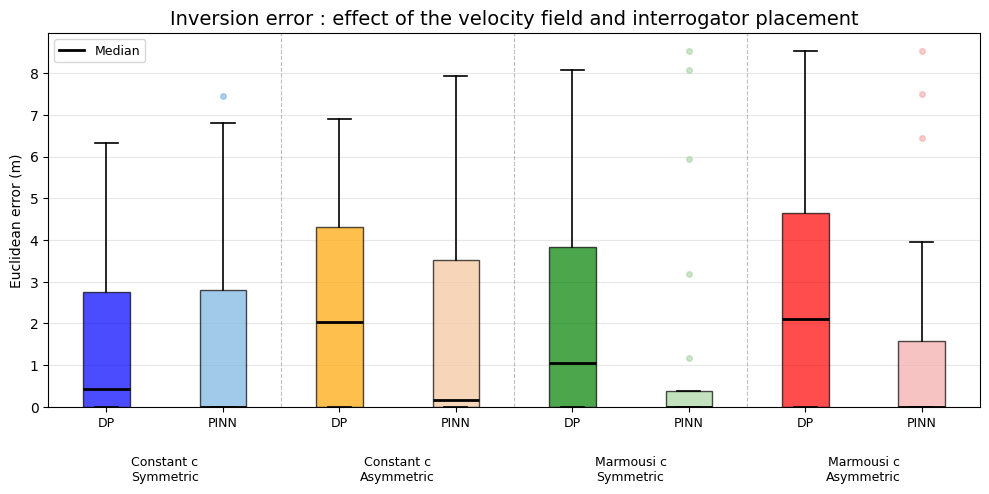

In [97]:
fig, ax = plt.subplots(figsize=(10, 5))

configs_short = ["DP", "PINN"] * 4

group_labels = [
    "Constant c\nSymmetric",
    "Constant c\nAsymmetric",
    "Marmousi c\nSymmetric",
    "Marmousi c\nAsymmetric",
]

all_errors = [
    errors_const, errors_const_pinn,
    errors_const2, errors_const2_pinn,
    errors_hetero, errors_hetero_pinn,
    errors_hetero2, errors_hetero2_pinn,
]

colors = [
    COLOR_CONST_SYM,  COLOR_CONST_ASYM,   # Constant c Symmetric:  DP=blue,   PINN=light blue
    COLOR_MAR_SYM,  COLOR_MAR_ASYM,   # Constant c Asymmetric: DP=orange,   PINN=light orange
    COLOR_PINN_SYM,    COLOR_PINN_ASYM,     # Marmousi Symmetric:    DP=green, PINN=light green
    COLOR_PINN_MAR_SYM,    COLOR_PINN_MAR_ASYM,     # Marmousi Asymmetric:   DP=red, PINN=light red
]

bp = ax.boxplot(
    all_errors,
    positions=range(len(all_errors)),
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2, color="black"),
    capprops=dict(linewidth=1.2, color="black"),
    flierprops=dict(marker='o', markersize=4, alpha=0.6),
)

for patch, color, flier in zip(bp['boxes'], colors, bp['fliers']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Individual DP/PINN labels
ax.set_xticks(range(len(configs_short)))
ax.set_xticklabels(configs_short, fontsize=9)

# Group labels centered between each pair
y_pos = ax.get_ylim()[0] - 0.08 * (ax.get_ylim()[1] - ax.get_ylim()[0])
for g, label in enumerate(group_labels):
    center = g * 2 + 0.5
    ax.text(center, y_pos, label, ha="center", va="top",
            fontsize=9, transform=ax.transData)
    if g < len(group_labels) - 1:
        ax.axvline(g * 2 + 1.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_ylim(bottom=0)
ax.set_title("Inversion error : effect of the velocity field and interrogator placement", fontsize=14)
ax.set_ylabel("Euclidean error (m)")
ax.grid(True, alpha=0.3, axis="y")
plt.subplots_adjust(bottom=0.2)

legend_elements = [Line2D([0], [0], color="black", linewidth=2, label="Median")]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

##### Key metrics : 

Comparison between both solver : 

In [ ]:
batch_gap_marmousi = run_inversion_batch2(pinn_solver_marmousi, dp_hetero, epicenters)
batch_gap_const = run_inversion_batch2(pinn_solver_const, dp_const, epicenters)

In [ ]:
print("mean marmousi:", np.mean(batch_gap_marmousi))
print("std marmousi:", np.std(batch_gap_marmousi))
print("mean constant:", np.mean(batch_gap_const))
print("std constant:", np.std(batch_gap_const))

Individual key metrics : 

In [ ]:
print(f"DP Constant c Symmetric:   {np.median(errors_const):.3f} m")
print(f"PINN Constant c Symmetric: {np.median(errors_const_pinn):.3f} m")
print(f"DP Constant c Asymmetric:  {np.median(errors_const2):.3f} m")
print(f"PINN Constant c Asymmetric:{np.median(errors_const2_pinn):.3f} m")
print(f"DP Marmousi Symmetric:     {np.median(errors_hetero):.3f} m")
print(f"PINN Marmousi Symmetric:   {np.median(errors_hetero_pinn):.3f} m")
print(f"DP Marmousi Asymmetric:    {np.median(errors_hetero2):.3f} m")
print(f"PINN Marmousi Asymmetric:  {np.median(errors_hetero2_pinn):.3f} m")
threshold = 5.0  # adjust based on what you see in the plot
for name, errors in [("DP Const Sym", errors_const), ("PINN Const Sym", errors_const_pinn), ("DP Const Asym", errors_const2), ("PINN Const Asym", errors_const2_pinn), ("DP Marmousi Sym", errors_hetero), ("PINN Marmousi Sym", errors_hetero_pinn), ("DP Marmousi Asym", errors_hetero2), ("PINN Marmousi Asym", errors_hetero2_pinn)]:
    print(f"{name}: {(errors > threshold).sum()} outliers above {threshold}m")

DP Constant c Symmetric:   0.431 m
PINN Constant c Symmetric: 0.000 m
DP Constant c Asymmetric:  2.045 m
PINN Constant c Asymmetric:0.167 m
DP Marmousi Symmetric:     1.041 m
PINN Marmousi Symmetric:   0.000 m
DP Marmousi Asymmetric:    2.113 m
PINN Marmousi Asymmetric:  0.000 m
DP Const Sym: 1 outliers above 5.0m
PINN Const Sym: 3 outliers above 5.0m
DP Const Asym: 3 outliers above 5.0m
PINN Const Asym: 4 outliers above 5.0m
DP Marmousi Sym: 4 outliers above 5.0m
PINN Marmousi Sym: 3 outliers above 5.0m
DP Marmousi Asym: 4 outliers above 5.0m
PINN Marmousi Asym: 3 outliers above 5.0m


In [ ]:
for name, errors in [
    ("DP Const Sym", errors_const), 
    ("PINN Const Sym", errors_const_pinn),
    ("DP Const Asym", errors_const2), 
    ("PINN Const Asym", errors_const2_pinn),
    ("DP Mar Sym", errors_hetero), 
    ("PINN Mar Sym", errors_hetero_pinn),
    ("DP Mar Asym", errors_hetero2), 
    ("PINN Mar Asym", errors_hetero2_pinn),
]:
    q1, q3 = np.percentile(errors, [25, 75])
    iqr = q3 - q1
    n_outliers = ((errors < q1 - 1.5*iqr) | (errors > q3 + 1.5*iqr)).sum()
    print(f"{name}: {n_outliers} outliers (Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f})")

### Effect of number of sensors :
Compare the quality of the inversion with different number of seismometers. 

#### Differentiable solver :

In [ ]:
# Inversion results by number of sensors
results_by_k = {2: errors_hetero} # already computer for k=2
for k, sensors_k in [(3, sensors_3), (4, sensors_4)]:
    solver_k = make_dp(sensors_k, c_marmousi)
    errors_k = run_inversion_batch(solver_k, epicenters)
    results_by_k[k] = errors_k
    print(f"K={k} — mean: {errors_k.mean():.4f}  std: {errors_k.std():.4f}")
print(f"{results_by_k=}")

100%|██████████| 20/20 [07:19<00:00, 21.97s/it]


K=3 — mean: 2.2994  std: 3.0739


100%|██████████| 20/20 [07:02<00:00, 21.14s/it]

K=4 — mean: 1.8601  std: 2.9235


#### PINN : 

In [26]:
results_by_k_pinn_const = {2: errors_const_pinn}
for k, sensors_k in [(3, sensors_3), (4, sensors_4)]:
    solver_k_pinn = make_pinn(sensors_k, model_pinn_const)
    errors_k_pinn = run_inversion_batch(solver_k_pinn, epicenters)
    results_by_k_pinn_const[k] = errors_k_pinn
    print(f"K={k} — mean: {errors_k_pinn.mean():.4f}  std: {errors_k_pinn.std():.4f}")
print(f"{results_by_k_pinn_const=}")

100%|██████████| 20/20 [00:01<00:00, 15.09it/s]


K=3 — mean: 1.6343  std: 2.6195


100%|██████████| 20/20 [00:01<00:00, 12.46it/s]

K=4 — mean: 0.6237  std: 1.5857
results_by_k_pinn_const={2: array([2.98737632e-06, 4.00456578e-01, 7.83976702e-07, 3.57627869e-07,
       5.79281092e+00, 5.96046448e-08, 2.27749024e-06, 1.12114131e+00,
       8.84260589e-06, 3.37174782e-07, 8.77551913e-01, 4.76837158e-07,
       3.72711039e+00, 4.81854677e+00, 7.45558071e+00, 6.80692482e+00,
       6.42957048e-06, 2.56784665e-06, 1.19209290e-07, 2.49894309e+00]), 3: array([1.59936042e-06, 2.38200992e-01, 5.96046448e-08, 4.29815202e-07,
       6.38873816e+00, 3.57627869e-07, 4.17232513e-07, 3.76972878e-07,
       1.92219204e-06, 4.29815202e-07, 2.08382225e+00, 3.37174782e-07,
       5.40289497e+00, 6.34541368e+00, 5.32823706e+00, 6.89878941e+00,
       1.43051147e-06, 0.00000000e+00, 1.19209290e-07, 6.41961662e-07]), 4: array([2.38418579e-07, 4.34895128e-01, 1.33280039e-07, 5.33120158e-07,
       2.82888580e-02, 1.78813934e-07, 2.66560079e-07, 1.68587391e-07,
       5.96046448e-07, 1.19209290e-07, 4.18048614e-04, 0.00000000e+00,
       

In [ ]:
results_by_k_pinn_marmousi = {2: errors_hetero_pinn}
for k, sensors_k in [(3, sensors_3), (4, sensors_4)]:
    solver_k_pinn = make_pinn(sensors_k, model_pinn_marmousi)
    errors_k_pinn = run_inversion_batch(solver_k_pinn, epicenters)
    results_by_k_pinn_marmousi[k] = errors_k_pinn
    print(f"K={k} — mean: {errors_k_pinn.mean():.4f}  std: {errors_k_pinn.std():.4f}")
print(f"{results_by_k_pinn_marmousi=}")

100%|██████████| 20/20 [00:00<00:00, 22.37it/s]


K=3 — mean: 1.1862  std: 2.5074


100%|██████████| 20/20 [00:01<00:00, 17.78it/s]

K=4 — mean: 1.3644  std: 2.7917
results_by_k_pinn_marmousi={2: array([2.38418579e-07, 1.16930699e+00, 8.42936956e-08, 1.19209290e-07,
       9.34833139e-02, 4.29815202e-07, 4.76837158e-07, 2.66560079e-07,
       2.38418579e-07, 1.68587391e-07, 1.68047991e-04, 3.37174782e-07,
       8.53702736e+00, 5.92867327e+00, 8.07855034e+00, 1.28237948e-01,
       2.45756240e-07, 0.00000000e+00, 4.29815202e-07, 3.18185949e+00]), 3: array([7.53945756e-07, 6.78195894e-01, 8.53408665e-07, 1.19209290e-07,
       2.61803567e-02, 5.87037675e-07, 9.25312918e-07, 2.18839159e-06,
       1.78813934e-07, 9.31054331e-07, 4.04428053e+00, 3.37174782e-07,
       8.53702736e+00, 7.50348902e+00, 2.80406332e+00, 1.30542204e-01,
       8.67856727e-07, 8.59630404e-07, 2.38418579e-07, 5.96046448e-08]), 4: array([2.38418579e-07, 1.74718097e-01, 3.76972878e-07, 0.00000000e+00,
       2.61772890e-02, 9.83024961e-07, 7.74860382e-07, 1.78813934e-07,
       0.00000000e+00, 1.68587391e-07, 4.38760471e+00, 3.37174782e-07,
    

#### Results : 

Plot the results as a boxplot : 

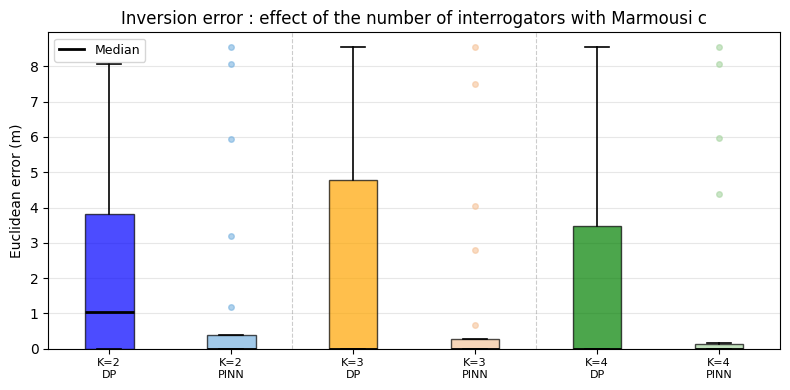

In [101]:
COLOR_K2_DP   = "blue"
COLOR_K3_DP   = "orange"
COLOR_K4_DP   = "green"
COLOR_K2_PINN ="#7AB3E0"
COLOR_K3_PINN = "#F5C49A"
COLOR_K4_PINN = "#A8D5A2"

configs = ["K=2\nDP", "K=2\nPINN", 
           "K=3\nDP", "K=3\nPINN", 
           "K=4\nDP", "K=4\nPINN"]

all_errors = [
    results_by_k[2], results_by_k_pinn_marmousi[2], 
    results_by_k[3], results_by_k_pinn_marmousi[3], 
    results_by_k[4], results_by_k_pinn_marmousi[4]
]

colors = [
    COLOR_K2_DP, COLOR_K2_PINN,
    COLOR_K3_DP, COLOR_K3_PINN,
    COLOR_K4_DP, COLOR_K4_PINN,
]

fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(
    all_errors,
    positions=range(len(all_errors)),
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2, color="black"),
    capprops=dict(linewidth=1.2, color="black"),
    flierprops=dict(marker='o', markersize=4, alpha=0.6),
)

for patch, color, flier in zip(bp['boxes'], colors, bp['fliers']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# vertical separators between K groups
for x in [1.5, 3.5]:
    ax.axvline(x, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs, fontsize=8)
ax.set_ylim(bottom=0)
ax.set_title("Inversion error : effect of the number of interrogators with Marmousi c")
ax.set_ylabel("Euclidean error (m)")
ax.grid(True, alpha=0.3, axis="y")

legend_elements = [Line2D([0], [0], color="black", linewidth=2, label="Median")]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

Some key metrics : 

In [112]:
for name, errors in [
    ("DP K=2", results_by_k[2]),
    ("DP K=3", results_by_k[3]),
    ("DP K=4", results_by_k[4]),
    ("PINN K=2", results_by_k_pinn_marmousi[2]),
    ("PINN K=3", results_by_k_pinn_marmousi[3]),
    ("PINN K=4", results_by_k_pinn_marmousi[4]),
]:
    q1, q3 = np.percentile(errors, [25, 75])
    iqr = q3 - q1
    n_outliers = ((errors < q1 - 1.5*iqr) | (errors > q3 + 1.5*iqr)).sum()
    print(f"{name}: median={np.median(errors):.3f} outliers={n_outliers} IQR={iqr:.2f}")

DP K=2: median=1.041 outliers=0 IQR=3.82
DP K=3: median=0.000 outliers=0 IQR=4.77
DP K=4: median=0.000 outliers=0 IQR=3.48
PINN K=2: median=0.000 outliers=5 IQR=0.39
PINN K=3: median=0.000 outliers=5 IQR=0.27
PINN K=4: median=0.000 outliers=4 IQR=0.13


### Sensitivity to initial guess : 
Analyze the sensitivity to the initial epicenter estimate on the Marmousi veloxity structure. One epicenter is used as reference a for comparison between starting points.

#### Trajectories computation : 

In [ ]:
# Trajectories for the differentiable solver  
ex_test, ey_test = 1.5, 1.0
traces_obs = dp_hetero.forward(ex_test, ey_test).detach()
inits = [(-3,-3), (-3,3), (3,-3), (3,3), (0,0), (1,1)]

init_histories = {}
for init in tqdm(inits):
    _, _, _, history = inverse_function(
        forward=dp_hetero, traces_obs=traces_obs,
        dt=dp_hetero.dt, init=init,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    init_histories[init] = np.array([init] + history)

100%|██████████| 6/6 [02:05<00:00, 21.00s/it]


In [ ]:
# # Trajectories for the PINN
ex_test, ey_test = 1.5, 1.0
traces_obs_pinn = pinn_solver_marmousi.forward(ex_test, ey_test).detach()
inits = [(-3,-3), (-3,3), (3,-3), (3,3), (0,0), (1,1)]

init_histories_pinn_marmousi = {}
for init in tqdm(inits):
    _, _, _, history = inverse_function(
        forward=pinn_solver_marmousi, traces_obs=traces_obs_pinn,
        dt=pinn_solver_marmousi.dt, init=init,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    init_histories_pinn_marmousi[init] = np.array([init] + history)

#### Results : 

Trajectories of the differentiable solver : 

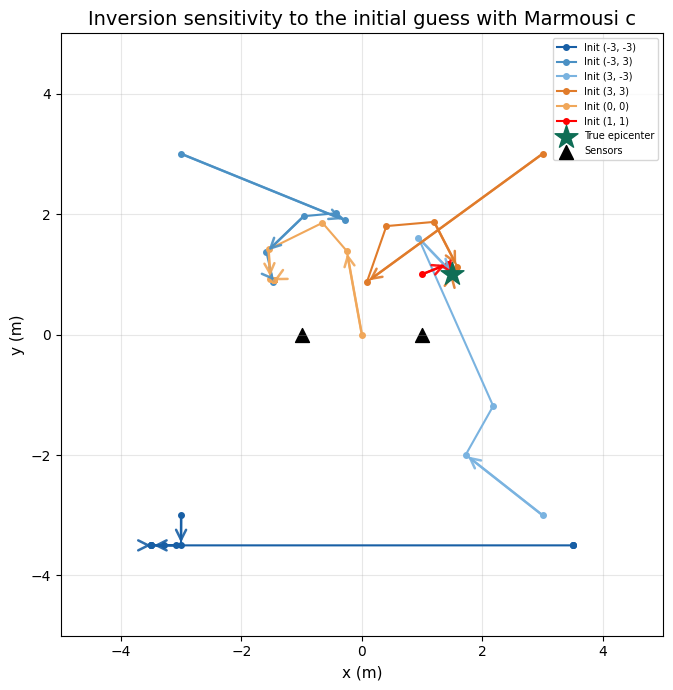

In [53]:
colors = [
    "#185FA5",  # dark blue
    "#4A90C4",  # medium blue
    "#7AB3E0",  # light blue
    "#E07B2A",  # dark orange
    "#F0A75A",  # medium orange
    "red",
]

fig, ax = plt.subplots(figsize=(7, 7))
for (init, history), color in zip(init_histories.items(), colors):

    # trajectory
    ax.plot(history[:, 0], history[:, 1], "o-", color=color, linewidth=1.5, markersize=4, label=f"Init {init}")

    # arrows showing convergence direction
    for i in range(0, len(history)-1, 3):
        ax.annotate(
            "",
            xy=(history[i + 1, 0], history[i + 1, 1]),
            xytext=(history[i, 0], history[i, 1]),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.8, mutation_scale=18, alpha=0.9,),
        )

ax.scatter(ex_test, ey_test,marker="*", color="#0F6E56", s=300, zorder=6, label="True epicenter")
ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=100, label="Sensors")

ax.set_title("Inversion sensitivity to the initial guess with Marmousi c", fontsize=14)
ax.set_xlabel("x (m)", fontsize=11)
ax.set_ylabel("y (m)", fontsize=11)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

ax.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.show()

Trajectories of the PINN : 

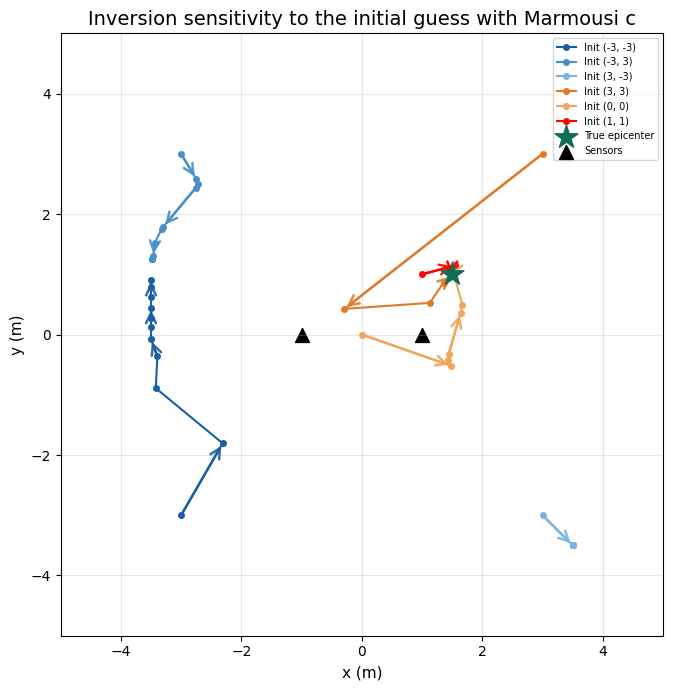

In [50]:
colors = [
    "#185FA5",  # dark blue
    "#4A90C4",  # medium blue
    "#7AB3E0",  # light blue
    "#E07B2A",  # dark orange
    "#F0A75A",  # medium orange
    "red",
]

fig, ax = plt.subplots(figsize=(7, 7))
for (init, history), color in zip(init_histories_pinn_marmousi.items(), colors):

    # trajectory
    ax.plot(history[:, 0], history[:, 1], "o-", color=color, linewidth=1.5, markersize=4, label=f"Init {init}")

    # arrows showing convergence direction
    for i in range(0, len(history)-1, 3):
        ax.annotate(
            "",
            xy=(history[i + 1, 0], history[i + 1, 1]),
            xytext=(history[i, 0], history[i, 1]),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.8, mutation_scale=18, alpha=0.9,),
        )

ax.scatter(ex_test, ey_test,marker="*", color="#0F6E56", s=300, zorder=6, label="True epicenter")
ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=100, label="Sensors")

ax.set_title("Inversion sensitivity to the initial guess with Marmousi c", fontsize=14)
ax.set_xlabel("x (m)", fontsize=11)
ax.set_ylabel("y (m)", fontsize=11)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

ax.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.show()

### Error heatmap :
Divide the domain where the earthquakes can occur into smaller rectangles and compute the distance error for each part.

#### Computation : 
Differentiable solver : 

In [ ]:
grid_n = 6  # Number of points along each axis for the error map
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps = {}
# Compute error maps for the differentiable solver on both velocity fields
for solver, label in [(dp_const, "Constant c"), (dp_hetero, "Heterogeneous c")]:
    error_map = np.zeros((grid_n, grid_n))
    for i in range(grid_n):
        print(f"Processing {label} — Row {i+1}/{grid_n}")
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = solver.forward(ex, ey).detach()
            # Run a short inversion to get the estimated epicenter
            e_hat, _, _, _ = inverse_function(  
                forward=solver, traces_obs=traces_obs,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps[label] = error_map
print(f"{error_maps=}")


Processing Constant c — Row 1/6
Processing Constant c — Row 2/6
Processing Constant c — Row 3/6
Processing Constant c — Row 4/6
Processing Constant c — Row 5/6
Processing Constant c — Row 6/6
Processing Heterogeneous c — Row 1/6
Processing Heterogeneous c — Row 2/6
Processing Heterogeneous c — Row 3/6
Processing Heterogeneous c — Row 4/6
Processing Heterogeneous c — Row 5/6
Processing Heterogeneous c — Row 6/6
error_maps={'Constant c': array([[7.51664829e+00, 4.64347649e+00, 2.26526046e+00, 7.88263679e-01,
        5.32626987e-01, 7.07106769e-01],
       [7.57185555e+00, 4.80000019e+00, 1.60000038e+00, 3.57627869e-07,
        7.15255737e-07, 1.15456581e+00],
       [7.73840141e+00, 4.80000019e+00, 1.60000086e+00, 6.95103608e-07,
        1.01327896e-06, 1.97059977e+00],
       [7.89546204e+00, 4.80000067e+00, 1.59999967e+00, 2.14907601e-07,
        1.39530891e-06, 2.51760864e+00],
       [7.52668905e+00, 4.80000067e+00, 1.60000050e+00, 2.45756240e-07,
        2.38418579e-07, 8.06876659e-

PINN : 

In [ ]:
grid_n = 6  # reduced to save time
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps_pinn = {}
for solver, label in [(pinn_solver_const, "Constant c"), (pinn_solver_marmousi, "Marmousi c")]:
    error_map = np.zeros((  grid_n, grid_n))
    for i in range(grid_n):
        # print(f"Processing {label} — Row {i+1}/{grid_n}")
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = solver.forward(ex, ey).detach()
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_obs,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps_pinn[label] = error_map
print(f"{error_maps_pinn=}")

#### Results : 
Heatmaps, one for each solver on each velocity field :

Differentiable solver : 

/var/folders/z7/kf7_7b9n01b71nv2r1zvpqvm0000gn/T/ipykernel_52877/4002734836.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


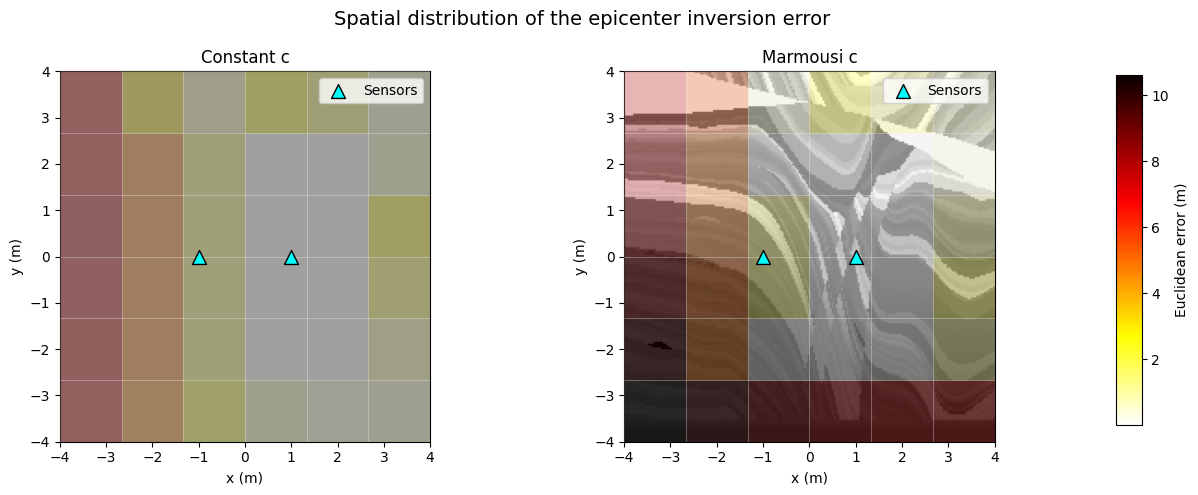

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, label in zip(axes, ["Constant c", "Marmousi c"]):
    error_map = error_maps[label]

    if label == "Constant c":
        ax.imshow(np.ones((2, 2)) * 0.5, extent=[-4, 4, -4, 4],
                  origin="lower", cmap="gray", aspect="equal",
                  vmin=0, vmax=1)
    else:
        ax.imshow(Z_bg.T, extent=[-4, 4, -4, 4], origin="lower",
                  cmap="gray", aspect="equal")

    # Replace scatter with filled rectangles
    for i in range(6):
        for j in range(6):
            color = cmap(norm(error_map[j, i]))
            rect = Rectangle((GX_c[j, i] - step/2, GY_c[j, i] - step/2),
                              step, step,
                              facecolor=color, alpha=0.25,
                              edgecolor="white", linewidth=0.5, zorder=5)
            ax.add_patch(rect)

    ax.scatter(sensors_2[:, 0], sensors_2[:, 1],
               marker="^", color="cyan", edgecolors="black",
               s=100, zorder=6, label="Sensors")
    ax.set_title(label)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right")
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cbar_ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the epicenter inversion error", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

PINN :

/var/folders/z7/kf7_7b9n01b71nv2r1zvpqvm0000gn/T/ipykernel_52877/3188410039.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


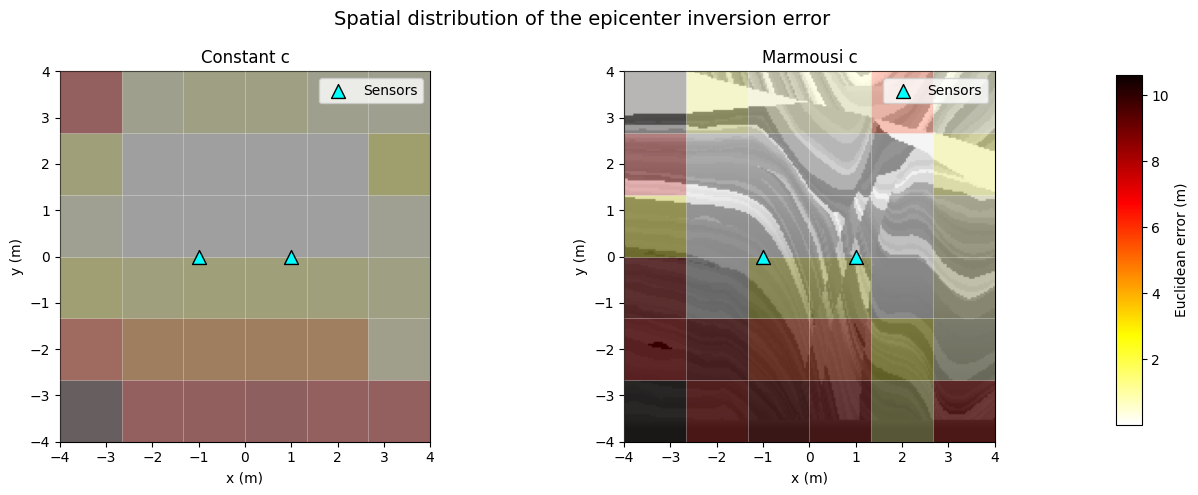

In [77]:
x_bg = np.linspace(-4, 4, 200)
y_bg = np.linspace(-4, 4, 200)
X_bg, Y_bg = np.meshgrid(x_bg, y_bg, indexing='ij')
Z_bg = c_marmousi(X_bg, Y_bg).numpy()

all_errors = np.concatenate([m.ravel() for m in error_maps_pinn.values()])
vmin, vmax = all_errors.min(), all_errors.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.hot_r

step = 8 / 6
gx_centers = np.linspace(-4 + step/2, 4 - step/2, 6)
gy_centers = np.linspace(-4 + step/2, 4 - step/2, 6)
GX_c, GY_c = np.meshgrid(gx_centers, gy_centers)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, label in zip(axes, ["Constant c", "Marmousi c"]):
    error_map = error_maps_pinn[label]

    if label == "Constant c":
        ax.imshow(np.ones((2, 2)) * 0.5, extent=[-4, 4, -4, 4],
                  origin="lower", cmap="gray", aspect="equal",
                  vmin=0, vmax=1)
    else:
        ax.imshow(Z_bg.T, extent=[-4, 4, -4, 4], origin="lower",
                  cmap="gray", aspect="equal")

    for i in range(6):
        for j in range(6):
            color = cmap(norm(error_map[j, i]))
            rect = Rectangle((GX_c[j, i] - step/2, GY_c[j, i] - step/2),
                              step, step,
                              facecolor=color, alpha=0.25,
                              edgecolor="white", linewidth=0.5, zorder=5)
            ax.add_patch(rect)

    ax.scatter(sensors_2[:, 0], sensors_2[:, 1],
               marker="^", color="cyan", edgecolors="black",
               s=100, zorder=6, label="Sensors")
    ax.set_title(label)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right")

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cbar_ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the epicenter inversion error", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### Noise robustness : 
Evaluate the robustness to noise of both solvers on both velocity fields.

#### Noise analysis : 
Differentiable solver : 

In [38]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
noise_results = {}

for solver, label, color in [(dp_const, "Constant c", "blue"), (dp_hetero, "Marmousi c", "orange")]:
    traces_clean = solver.forward(ex_test, ey_test).detach()
    mean_errors, std_errors = [], []
    for sigma_n in noise_levels:
        errs = []
        for _ in range(10):
            noise = torch.randn_like(traces_clean) * sigma_n * traces_clean.std(dim=0)
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_clean + noise,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            errs.append(((e_hat[0]-ex_test)**2 + (e_hat[1]-ey_test)**2).sqrt().item())
        mean_errors.append(np.mean(errs))
        std_errors.append(np.std(errs))
    noise_results[label] = {"mean": mean_errors, "std": std_errors, "color": color}
print(f"{noise_results=}")

noise_results={'Constant c': {'mean': [np.float64(2.4575624024691933e-07), np.float64(0.0008803107142739463), np.float64(0.004210960853379219), np.float64(0.010005953954532743)], 'std': [np.float64(0.0), np.float64(0.0004810416638445372), np.float64(0.0019638126385262233), np.float64(0.003593863308871792)], 'color': 'blue'}, 'Marmousi c': {'mean': [np.float64(9.310543305218744e-07), np.float64(0.0008556223008781671), np.float64(0.005044185498263687), np.float64(0.0070089940447360275)], 'std': [np.float64(0.0), np.float64(0.0004884866372811528), np.float64(0.002554000381906741), np.float64(0.00422314134960107)], 'color': 'orange'}}


PINN : 

In [ ]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
noise_results_pinn = {}

for solver, label, color in [(pinn_solver_const, "Constant c", "blue"), (pinn_solver_marmousi, "Marmousi c", "orange")]:
    traces_clean = solver.forward(ex_test, ey_test).detach()
    mean_errors, std_errors = [], []
    for sigma_n in noise_levels:
        errs = []
        for _ in range(10):
            noise = torch.randn_like(traces_clean) * sigma_n * traces_clean.std(dim=0)
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_clean + noise,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            errs.append(((e_hat[0]-ex_test)**2 + (e_hat[1]-ey_test)**2).sqrt().item())
        mean_errors.append(np.mean(errs))
        std_errors.append(np.std(errs))
    noise_results_pinn[label] = {"mean": mean_errors, "std": std_errors, "color": color}
print(f"{noise_results_pinn=}")

#### Results : 
Differentiable solver : 

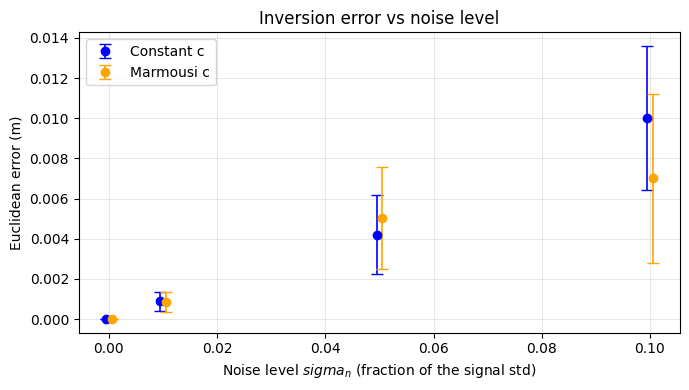

In [ ]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
offset = 0.0005
offsets = {"Constant c": -offset, "Marmousi c": +offset}

fig, ax = plt.subplots(figsize=(7, 4))

for label, data in noise_results.items():
    # Points with error bars only, no connecting line
    x = np.array(noise_levels) + offsets[label]
    ax.errorbar(x, data["mean"], yerr=data["std"],
            marker="o", linewidth=0, elinewidth=1.2, capsize=4,
            color=data["color"], label=label)

ax.set_title("Inversion error vs noise level")
ax.set_xlabel("Noise level $\\sigma_n$ (fraction of the signal std)")
ax.set_ylabel("Euclidean error (m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PINN : 

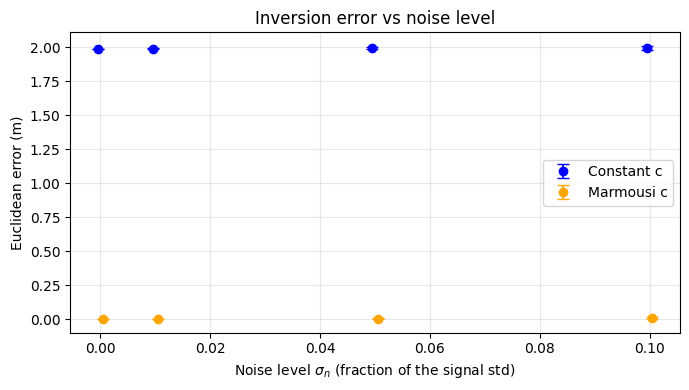

In [ ]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
offset = 0.0005
offsets = {"Constant c": -offset, "Marmousi c": +offset}

fig, ax = plt.subplots(figsize=(7, 4))

for label, data in noise_results_pinn.items():
    # Points with error bars only, no connecting line
    x = np.array(noise_levels) + offsets[label]
    ax.errorbar(x, data["mean"], yerr=data["std"],
            marker="o", linewidth=0, elinewidth=1.2, capsize=4,
            color=data["color"], label=label)

ax.set_title("Inversion error vs noise level")
ax.set_xlabel("Noise level $\\sigma_n$ (fraction of the signal std)")
ax.set_ylabel("Euclidean error (m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Runtime benchmark : 
Measure the time taken for each solver on the Marmousi for the forward pass and the full inversion. 

Differentiable solver :

In [ ]:
import time

traces_obs = dp_hetero.forward(0, 0).detach()
n_runs = 5
times_fwd, times_inv = [], []

# Loop to measure forward and inversion times for the differentiable solver
for _ in tqdm(range(n_runs)):
    t0 = time.perf_counter()
    dp_hetero.forward(0, 0)
    times_fwd.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    inverse_function(
        forward=dp_hetero, traces_obs=traces_obs,
        dt=dp_hetero.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    times_inv.append(time.perf_counter() - t0)

print(f"DP forward   — mean: {np.mean(times_fwd):.3f}s  std: {np.std(times_fwd):.3f}s")
print(f"DP inversion — mean: {np.mean(times_inv):.3f}s  std: {np.std(times_inv):.3f}s")

100%|██████████| 5/5 [01:33<00:00, 18.64s/it]

DP forward   — mean: 0.241s  std: 0.014s
DP inversion — mean: 18.394s  std: 0.290s


PINN : 

In [ ]:
traces_obs = pinn_solver_marmousi.forward(0, 0).detach()
n_runs = 5

times_fwd, times_inv = [], []

# Loop to measure forward and inversion times for the PINN solver
for _ in tqdm(range(n_runs)):
    t0 = time.perf_counter()
    pinn_solver_marmousi.forward(0, 0)
    times_fwd.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    inverse_function(
        forward=pinn_solver_marmousi, traces_obs=traces_obs,
        dt=pinn_solver_marmousi.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    times_inv.append(time.perf_counter() - t0)

print(f"PINN forward   — mean: {np.mean(times_fwd):.3f}s  std: {np.std(times_fwd):.3f}s")
print(f"PINN inversion — mean: {np.mean(times_inv):.3f}s  std: {np.std(times_inv):.3f}s")

100%|██████████| 5/5 [00:00<00:00, 34.91it/s]

PINN forward   — mean: 0.001s  std: 0.000s
PINN inversion — mean: 0.028s  std: 0.009s


### Interrogator placement : 
We formulate interrogator placement as a bilevel optimization problem.
The outer loop minimizes mean inversion error over the 20 test epicenters by adjusting sensor positions.
The inner loop runs the epicenter inversion for each candidate placement.

We first run gradient-based outer optimization with `optimize_sensors` for 100 steps.
We then refine it with `local_search`. This perturbs one sensor at a time and keeps
improvements, acting as an iterated local search around the gradient-based solution.
The final evaluation uses the differentiable solver as ground truth,
to avoid measuring performance on the same model used for optimization.

In [ ]:
# Test epicenters for the optimization
torch.manual_seed(42)
N_EPI_OPT = 20
epicenters_opt = torch.rand(N_EPI_OPT, 2) * 8 - 4  # uniform in [-4, 4]^2


# Find a first more optimal sensor placement with the PINN 
sensors_opt_pinn, history = optimize_sensors(
    pinn_model=model_pinn_const,
    sensors_init=sensors_2.clone(),
    epicenters=epicenters_opt,
    inner_steps=1, inner_lr=0.05,
    outer_steps=100, outer_lr=0.01,
    device="cpu",
)

# Use Iterated Local Search with PINN to find a better interrogator placement.
# Start from the optimized placement found above, and explore the neighborhood 
# by randomly perturbing one sensor at a time.
sensors_best, best_loss = local_search(
    pinn_model=model_pinn_const,
    sensors_best=sensors_opt_pinn,
    epicenters=epicenters_opt,
    n_neighbors=10,
    device="cpu",
)

#### Evaluation the quality : 
Evaluate the quality of the optimized placement with differentiable solver as ground truth.

In [ ]:
# Evaluate the quality of the optimized placement with DP as ground truth
print(f"Initial sensors:   {sensors_2.numpy()}")
print(f"Optimized sensors: {sensors_best.numpy()}")

err_opt_dp = run_inversion_batch(make_dp(sensors_best, c_constant), epicenters)

print(f"Initial DP:     mean={errors_const.mean():.4f}")
print(f"DP optimized:   mean={err_opt_dp.mean():.4f}")

Initial sensors:   [[-1.  0.]
 [ 1.  0.]]
Optimized sensors: [[-0.80252224  1.5035384 ]
 [-1.2182003   0.7559509 ]]


100%|██████████| 20/20 [07:12<00:00, 21.62s/it]

Initial DP:     mean=1.4991
Initial PINN:   mean=1.6750
DP optimized:   mean=1.1058


#### Plot results : 
Results are plotted with a boxplot and the error heatmaps to visualize the difference between the initial configuration and the optimized one.

##### Boxplot : 

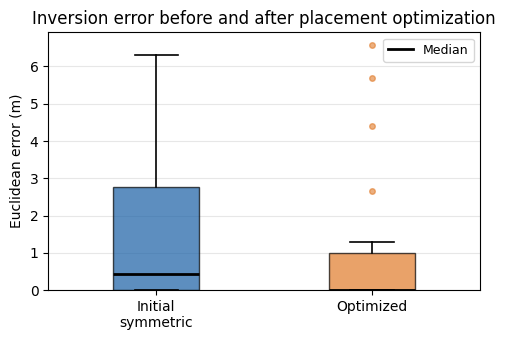

In [107]:
all_errors = [errors_const, err_opt_dp]
configs = ["Initial\nsymmetric", "Optimized"]
colors = ["#185FA5", "#E07B2A"]

fig, ax = plt.subplots(figsize=(5, 3.5))

bp = ax.boxplot(
    all_errors,
    positions=range(len(all_errors)),
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2, color="black"),
    capprops=dict(linewidth=1.2, color="black"),
    flierprops=dict(marker='o', markersize=4, alpha=0.6),
)

for patch, color, flier in zip(bp['boxes'], colors, bp['fliers']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs)
ax.set_ylim(bottom=0)
ax.set_ylabel("Euclidean error (m)")
ax.set_title("Inversion error before and after placement optimization")
ax.grid(True, alpha=0.3, axis="y")

ax.legend(handles=[Line2D([0], [0], color="black", linewidth=2, label="Median")],
          fontsize=9)
plt.tight_layout()
plt.show()

Key metrics : 

In [113]:
print(f"Initial median:   {np.median(errors_const):.3f} m")
print(f"Optimized median: {np.median(err_opt_dp):.3f} m")
q1, q3 = np.percentile(errors_const, [25, 75])
iqr = q3 - q1
n_out = ((errors_const < q1 - 1.5*iqr) | (errors_const > q3 + 1.5*iqr)).sum()
print(f"Initial outliers: {n_out}, IQR={iqr:.3f}")
q1, q3 = np.percentile(err_opt_dp, [25, 75])
iqr = q3 - q1
n_out = ((err_opt_dp < q1 - 1.5*iqr) | (err_opt_dp > q3 + 1.5*iqr)).sum()
print(f"Optimized outliers: {n_out}, IQR={iqr:.3f}")

Initial median:   0.431 m
Optimized median: 0.001 m
Initial outliers: 0, IQR=2.761
Optimized outliers: 4, IQR=0.985


##### Error heatmaps : 
Compute the heatmpas value using the PINN (fastest, less accurate) : 

In [80]:
# Computation cell
grid_n = 6
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps_placement = {}
for sensors_k, label in [(sensors_2, "Initial symmetric"), 
                          (sensors_best, "Optimized")]:
    pinn_k = make_pinn(sensors_k, model_pinn_const)
    error_map = np.zeros((grid_n, grid_n))
    for i in range(grid_n):
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = pinn_k.forward(ex, ey).detach()
            e_hat, _, _, _ = inverse_function(
                forward=pinn_k, traces_obs=traces_obs,
                dt=pinn_k.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps_placement[label] = (error_map, sensors_k)

Plot the heatmaps : 

/var/folders/z7/kf7_7b9n01b71nv2r1zvpqvm0000gn/T/ipykernel_52877/1911668180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


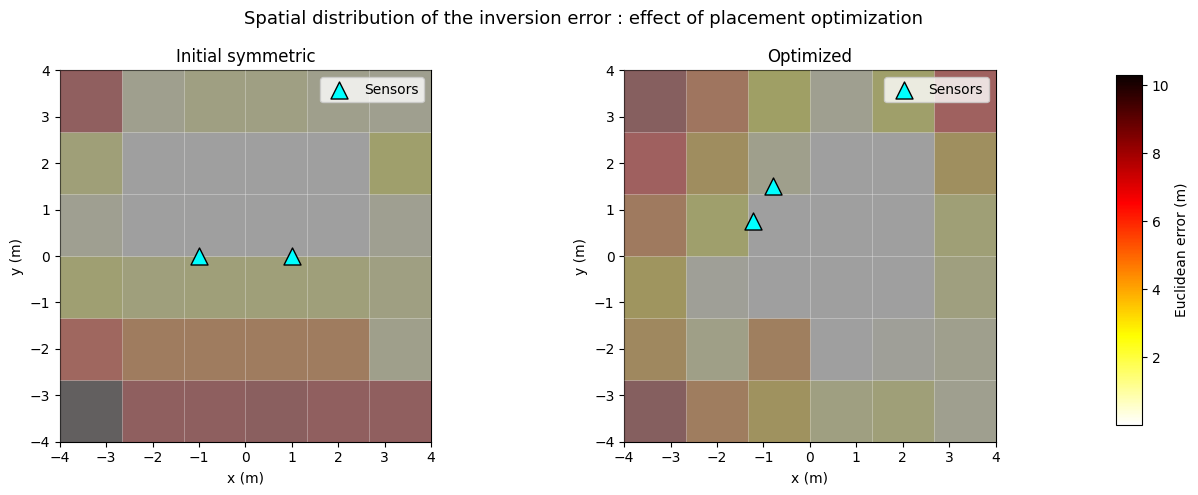

In [ ]:
all_errors = np.concatenate([m.ravel() for m, _ in error_maps_placement.values()])
vmin, vmax = all_errors.min(), all_errors.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.hot_r

step = 8 / 6
gx_centers = np.linspace(-4 + step/2, 4 - step/2, 6)
gy_centers = np.linspace(-4 + step/2, 4 - step/2, 6)
GX_c, GY_c = np.meshgrid(gx_centers, gy_centers)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, (error_map, sensors_k)) in zip(axes, error_maps_placement.items()):
    ax.imshow(np.ones((2, 2)) * 0.5, extent=[-4, 4, -4, 4],
              origin="lower", cmap="gray", aspect="equal",
              vmin=0, vmax=1)

    for i in range(6):
        for j in range(6):
            color = cmap(norm(error_map[j, i]))
            rect = Rectangle((GX_c[j, i] - step/2, GY_c[j, i] - step/2),
                              step, step,
                              facecolor=color, alpha=0.25,
                              edgecolor="white", linewidth=0.5, zorder=5)
            ax.add_patch(rect)

    ax.scatter(sensors_k[:, 0].numpy(), sensors_k[:, 1].numpy(),
               marker="^", color="cyan", edgecolors="black",
               s=150, zorder=6, label="Sensors")

    ax.set_title(label)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right")

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cbar_ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the inversion error : effect of placement optimization",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()